# POC: Análisis de Experiencia del Cliente mediante PLN
## Procesamiento de Lenguaje Natural - Universidad de La Sabana

### Descripción del Proyecto
Este notebook implementa una **Prueba de Concepto (POC)** para el análisis automatizado de reseñas de clientes de Amazon, integrando tres módulos de Procesamiento de Lenguaje Natural:

1. **Módulo de Análisis de Sentimientos** — Clasificación supervisada (Positivo/Negativo/Neutro)
2. **Módulo de Identificación de Temas** — Topic Modeling con LDA
3. **Módulo de Análisis Sintáctico-Semántico** — POS Tagging, NER, patrones lingüísticos

### Dataset
- **Fuente**: Amazon Review Data (Web Scrapping)
- **Variables**: `Review_text` (entrada), `Own_Rating` (etiqueta supervisada: Positive/Negative/Neutral)
- **Categorías de producto**: smartTv, mobile, books, refrigerator, mobile accessories

### Técnicas Utilizadas
- Tokenización, Lematización, Eliminación de stopwords
- Representación vectorial: TF-IDF
- Modelos: Logistic Regression, Multinomial Naive Bayes, SVM, Random Forest
- Evaluación: Accuracy, Precision, Recall, F1-score, Matriz de Confusión, Cross-Validation
- Topic Modeling: LDA (Latent Dirichlet Allocation)
- Análisis Sintáctico: POS Tagging, Dependency Parsing, patrones ADJ+NOUN

---
## 1. Importación de Librerías y Descarga de Recursos

Se importan las librerías necesarias para preprocesamiento, representación vectorial, clasificación, modelado de temas y análisis sintáctico.

In [1]:
# ============================================================
# 1. Importación de Librerías
# ============================================================

# Data manipulation & visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

# NLTK - Tokenización, Stopwords, Lematización
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# spaCy - Análisis Sintáctico y Semántico
import spacy

# scikit-learn - Representación Vectorial y Clasificación
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)

# Gensim - Topic Modeling (LDA)
import gensim
from gensim import corpora
from gensim.models import LdaModel

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# ============================================================
# Descarga de recursos NLTK y carga de modelo spaCy
# ============================================================

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Cargar modelo de spaCy para inglés
nlp = spacy.load("en_core_web_sm")

print("Recursos NLTK descargados y modelo spaCy cargado.")

Recursos NLTK descargados y modelo spaCy cargado.


---
## 2. Carga y Exploración del Dataset

Se carga el dataset de Amazon Reviews y se realiza una exploración inicial para comprender la estructura de los datos, la distribución de las etiquetas de sentimiento y las categorías de productos.

In [3]:
# ============================================================
# 2.1 Carga del Dataset
# ============================================================

DATA_PATH = "Amazon Review Data Web Scrapping - Amazon Review Data Web Scrapping.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nPrimeras 5 filas:")
df.head()

Dataset cargado: 60889 filas x 6 columnas

Columnas: ['Unique_ID', 'Category', 'Review_Header', 'Review_text', 'Rating', 'Own_Rating']

Tipos de datos:
Unique_ID        int64
Category           str
Review_Header      str
Review_text        str
Rating           int64
Own_Rating         str
dtype: object

Primeras 5 filas:


,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating
0,136040,smartTv,Nice one,I liked it,5,Positive
1,134236,mobile,Huge battery life with amazing display,I bought the phone on Amazon and been using my...,5,Positive
2,113945,books,Four Stars,"Awesome book at reasonable price, must buy ......",4,Positive
3,168076,smartTv,Nice quality,good,5,Positive
4,157302,books,Nice book,"The book is fine,not bad,contains nice concept...",3,Neutral


In [4]:
# ============================================================
# 2.2 Exploración de Datos
# ============================================================

# Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal de filas con Review_text nulo: {df['Review_text'].isnull().sum()}")

# Eliminar filas sin texto de reseña
df = df.dropna(subset=['Review_text']).reset_index(drop=True)
print(f"\nDataset después de limpiar nulos: {df.shape[0]} filas")

Valores nulos por columna:
Unique_ID         0
Category          0
Review_Header     5
Review_text      32
Rating            0
Own_Rating        0
dtype: int64

Total de filas con Review_text nulo: 32

Dataset después de limpiar nulos: 60857 filas


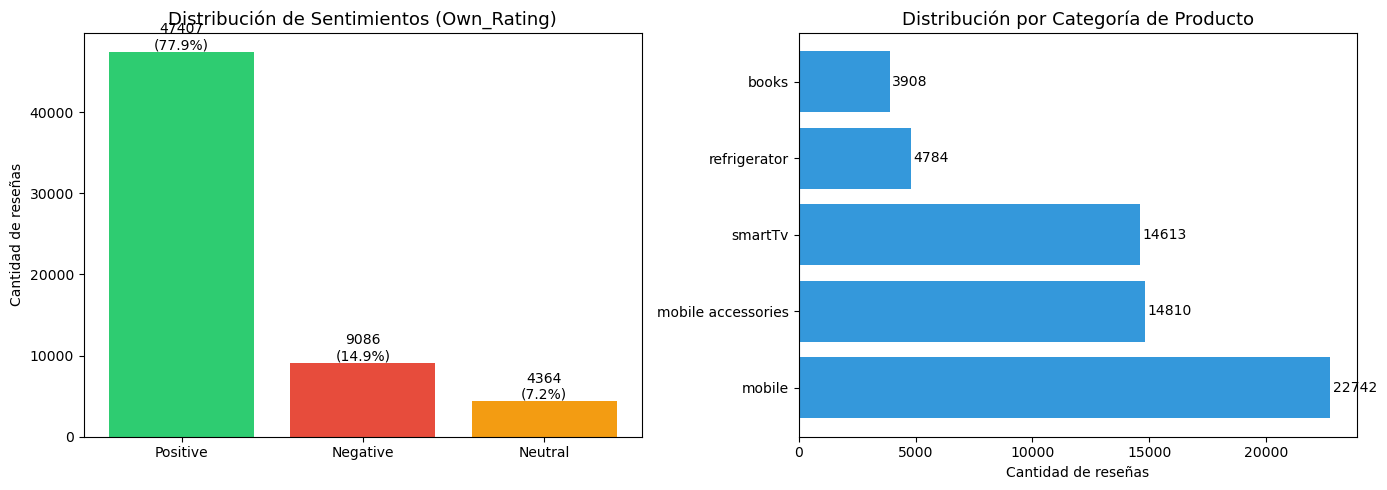


Distribución de sentimientos:
Own_Rating
Positive    47407
Negative     9086
Neutral      4364
Name: count, dtype: int64


In [5]:
# ============================================================
# 2.3 Distribución de Sentimientos y Categorías
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de sentimientos (Own_Rating)
sentiment_counts = df['Own_Rating'].value_counts()
colors_sentiment = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}
axes[0].bar(sentiment_counts.index, sentiment_counts.values,
            color=[colors_sentiment.get(x, '#95a5a6') for x in sentiment_counts.index])
axes[0].set_title('Distribución de Sentimientos (Own_Rating)', fontsize=13)
axes[0].set_ylabel('Cantidad de reseñas')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 300, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Distribución de categorías de producto
category_counts = df['Category'].value_counts()
axes[1].barh(category_counts.index, category_counts.values, color='#3498db')
axes[1].set_title('Distribución por Categoría de Producto', fontsize=13)
axes[1].set_xlabel('Cantidad de reseñas')
for i, v in enumerate(category_counts.values):
    axes[1].text(v + 100, i, f'{v}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nDistribución de sentimientos:")
print(df['Own_Rating'].value_counts())

In [7]:
# ============================================================
# 2.4 Muestra Estratificada para el POC
# ============================================================
# Para eficiencia del POC, trabajamos con una muestra representativa
# manteniendo la proporción de cada clase de sentimiento

SAMPLE_SIZE = 10000

samples = []
for label in df['Own_Rating'].unique():
    subset = df[df['Own_Rating'] == label]
    n = min(len(subset), int(SAMPLE_SIZE * len(subset) / len(df)))
    samples.append(subset.sample(n=n, random_state=42))

df_sample = pd.concat(samples).reset_index(drop=True)

print(f"Muestra para el POC: {len(df_sample)} reseñas")
print(f"\nDistribución en la muestra:")
print(df_sample['Own_Rating'].value_counts())
print(f"\nProporción preservada:")
print(df_sample['Own_Rating'].value_counts(normalize=True).round(3))

Muestra para el POC: 9999 reseñas

Distribución en la muestra:
Own_Rating
Positive    7789
Negative    1493
Neutral      717
Name: count, dtype: int64

Proporción preservada:
Own_Rating
Positive    0.779
Negative    0.149
Neutral     0.072
Name: proportion, dtype: float64


---
## 3. Pipeline de Preprocesamiento de Texto

Se implementa un pipeline completo de preprocesamiento que incluye:
- Limpieza básica (HTML, URLs, emails, caracteres especiales)
- Normalización (minúsculas, eliminación de puntuación y números)
- Tokenización con NLTK
- Eliminación de stopwords
- Lematización con WordNetLemmatizer

Este pipeline sigue los patrones aprendidos en las sesiones de clase (text_preprocessing_comprehensive_solution).

In [8]:
# ============================================================
# 3.1 Clase TextPreprocessor (SRP: una clase, una responsabilidad)
# ============================================================

class TextPreprocessor:
    """Pipeline de preprocesamiento de texto para análisis de reseñas."""

    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

    def basic_cleaning(self, text):
        """Limpieza básica: HTML, URLs, emails, espacios."""
        if pd.isna(text):
            return ""
        text = str(text)
        text = re.sub(r'<[^>]+>', '', text)           # Eliminar HTML tags
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Eliminar URLs
        text = re.sub(r'\S+@\S+', '', text)            # Eliminar emails
        text = re.sub(r'\s+', ' ', text)               # Normalizar espacios
        return text.strip()

    def normalize_case(self, text):
        """Convertir a minúsculas."""
        return text.lower()

    def remove_punctuation(self, text):
        """Eliminar puntuación."""
        return text.translate(str.maketrans('', '', string.punctuation))

    def remove_numbers(self, text):
        """Eliminar números."""
        return re.sub(r'\d+', '', text)

    def tokenize(self, text):
        """Tokenización con NLTK."""
        return word_tokenize(text)

    def remove_stopwords(self, tokens):
        """Eliminar stopwords."""
        return [word for word in tokens if word not in self.stop_words]

    def lemmatize_words(self, tokens):
        """Lematización con WordNetLemmatizer."""
        return [self.lemmatizer.lemmatize(word) for word in tokens]

    def remove_short_words(self, tokens, min_length=2):
        """Eliminar palabras muy cortas."""
        return [word for word in tokens if len(word) >= min_length]

    def preprocess(self, text):
        """Pipeline completo de preprocesamiento."""
        text = self.basic_cleaning(text)
        text = self.normalize_case(text)
        text = self.remove_punctuation(text)
        text = self.remove_numbers(text)
        tokens = self.tokenize(text)
        tokens = self.remove_stopwords(tokens)
        tokens = self.remove_short_words(tokens)
        tokens = self.lemmatize_words(tokens)
        return ' '.join(tokens)

preprocessor = TextPreprocessor()
print("TextPreprocessor inicializado correctamente.")

TextPreprocessor inicializado correctamente.


In [9]:
# ============================================================
# 3.2 Aplicar Preprocesamiento al Dataset
# ============================================================

print("Aplicando preprocesamiento al dataset...")
df_sample['processed_text'] = df_sample['Review_text'].apply(preprocessor.preprocess)

# Verificar resultados
print(f"\nEjemplos de preprocesamiento:")
for i in range(3):
    print(f"\n--- Reseña {i+1} ---")
    print(f"Original:    {df_sample['Review_text'].iloc[i][:150]}...")
    print(f"Procesado:   {df_sample['processed_text'].iloc[i][:150]}...")
    print(f"Sentimiento: {df_sample['Own_Rating'].iloc[i]}")

# Eliminar filas donde el texto procesado quedó vacío
df_sample = df_sample[df_sample['processed_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"\nDataset final después de preprocesamiento: {len(df_sample)} reseñas")

Aplicando preprocesamiento al dataset...

Ejemplos de preprocesamiento:

--- Reseña 1 ---
Original:    Product quality is good... Camera quality ok... Best in class battery life.. some software lag and hang issue is there... Display is too good... Speak...
Procesado:   product quality good camera quality ok best class battery life software lag hang issue display good speaker quality poor...
Sentimiento: Positive

--- Reseña 2 ---
Original:    Nice product worth the money...
Procesado:   nice product worth money...
Sentimiento: Positive

--- Reseña 3 ---
Original:    Very good product i recently purchased it...
Procesado:   good product recently purchased...
Sentimiento: Positive

Dataset final después de preprocesamiento: 9976 reseñas


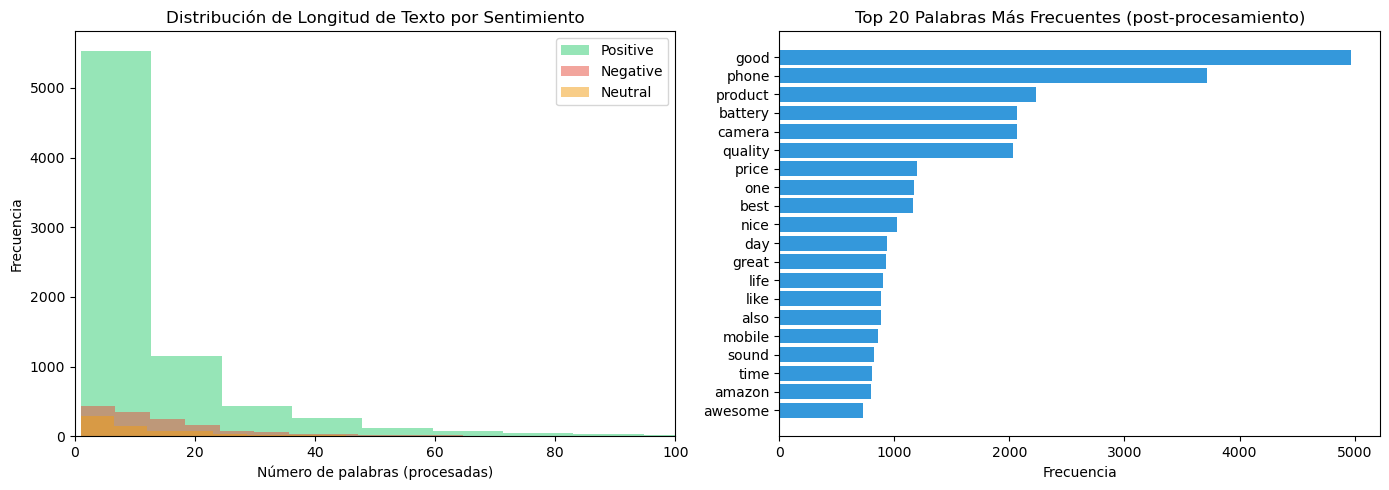


Estadísticas de longitud de texto procesado:
             count  mean   std  min  25%   50%   75%    max
Own_Rating                                                 
Negative    1490.0  16.6  18.4  1.0  5.0  11.0  21.0  290.0
Neutral      716.0  15.9  23.5  1.0  3.0   9.0  19.0  277.0
Positive    7770.0  13.6  26.7  1.0  2.0   6.0  14.0  587.0


In [10]:
# ============================================================
# 3.3 Análisis del Texto Preprocesado
# ============================================================

# Estadísticas de longitud de texto procesado
df_sample['text_length'] = df_sample['processed_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de longitud por sentimiento
for sentiment in ['Positive', 'Negative', 'Neutral']:
    subset = df_sample[df_sample['Own_Rating'] == sentiment]['text_length']
    axes[0].hist(subset, bins=50, alpha=0.5, label=sentiment,
                 color=colors_sentiment[sentiment])
axes[0].set_title('Distribución de Longitud de Texto por Sentimiento')
axes[0].set_xlabel('Número de palabras (procesadas)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].set_xlim(0, 100)

# Palabras más frecuentes
all_words = ' '.join(df_sample['processed_text']).split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)
axes[1].barh(range(len(words)), freqs, color='#3498db')
axes[1].set_yticks(range(len(words)))
axes[1].set_yticklabels(words)
axes[1].set_title('Top 20 Palabras Más Frecuentes (post-procesamiento)')
axes[1].set_xlabel('Frecuencia')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de longitud de texto procesado:")
print(df_sample.groupby('Own_Rating')['text_length'].describe().round(1))

---
## 4. Módulo 1: Análisis de Sentimientos — Clasificación Supervisada

### Objetivo
Clasificar automáticamente los comentarios en **Positivo**, **Negativo** o **Neutro** utilizando la variable `Own_Rating` como etiqueta supervisada.

### Técnicas
- **Representación vectorial**: TF-IDF (Term Frequency-Inverse Document Frequency)
- **Modelos**: Logistic Regression, Multinomial Naive Bayes, SVM, Random Forest
- **Evaluación**: Accuracy, Precision, Recall, F1-score, Cross-Validation, Matriz de Confusión

In [11]:
# ============================================================
# 4.1 Representación Vectorial con TF-IDF
# ============================================================

# Configuración del vectorizador TF-IDF
# (siguiendo patrones de bag_of_words_comprehensive.ipynb)
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),     # Unigramas y bigramas
    lowercase=True
)

# Variables X (features) e y (etiquetas)
X = tfidf_vectorizer.fit_transform(df_sample['processed_text'])
y = df_sample['Own_Rating']

print(f"Matriz TF-IDF: {X.shape}")
print(f"Vocabulario: {len(tfidf_vectorizer.vocabulary_)} términos")
print(f"Sparsidad: {(1 - X.nnz / (X.shape[0] * X.shape[1])) * 100:.2f}%")
print(f"\nDistribución de clases:")
print(y.value_counts())

Matriz TF-IDF: (9976, 5000)
Vocabulario: 5000 términos
Sparsidad: 99.71%

Distribución de clases:
Own_Rating
Positive    7770
Negative    1490
Neutral      716
Name: count, dtype: int64


In [12]:
# ============================================================
# 4.2 División Train/Test y Entrenamiento de Modelos
# ============================================================

# División estratificada 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

# Definir clasificadores (siguiendo bag_of_words_comprehensive.ipynb)
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM (Linear)': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Entrenar y evaluar cada modelo
results = {}
for name, clf in classifiers.items():
    print(f"\nEntrenando: {name}...")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Cross-validation (5-fold)
    cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')

    results[name] = {
        'model': clf,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'f1_weighted': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1 (weighted): {f1:.4f}")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\nEntrenamiento completado para todos los modelos.")

Conjunto de entrenamiento: 6983 muestras
Conjunto de prueba: 2993 muestras

Entrenando: Naive Bayes...
  Accuracy: 0.8296
  F1 (weighted): 0.7813
  CV Accuracy: 0.8375 (+/- 0.0023)

Entrenando: Logistic Regression...
  Accuracy: 0.8466
  F1 (weighted): 0.8088
  CV Accuracy: 0.8528 (+/- 0.0022)

Entrenando: SVM (Linear)...
  Accuracy: 0.8466
  F1 (weighted): 0.8103
  CV Accuracy: 0.8529 (+/- 0.0040)

Entrenando: Random Forest...
  Accuracy: 0.8376
  F1 (weighted): 0.8010
  CV Accuracy: 0.8464 (+/- 0.0040)

Entrenamiento completado para todos los modelos.


### 4.3 Evaluación Detallada de Modelos

Se evalúan los modelos con métricas completas: classification report y matrices de confusión para identificar el mejor clasificador.

COMPARACIÓN DE MODELOS
             Modelo  Accuracy  F1 (weighted)  CV Mean   CV Std
       SVM (Linear)  0.846642       0.810255 0.852947 0.004029
Logistic Regression  0.846642       0.808795 0.852847 0.002196
      Random Forest  0.837621       0.801022 0.846431 0.003983
        Naive Bayes  0.829602       0.781292 0.837510 0.002277


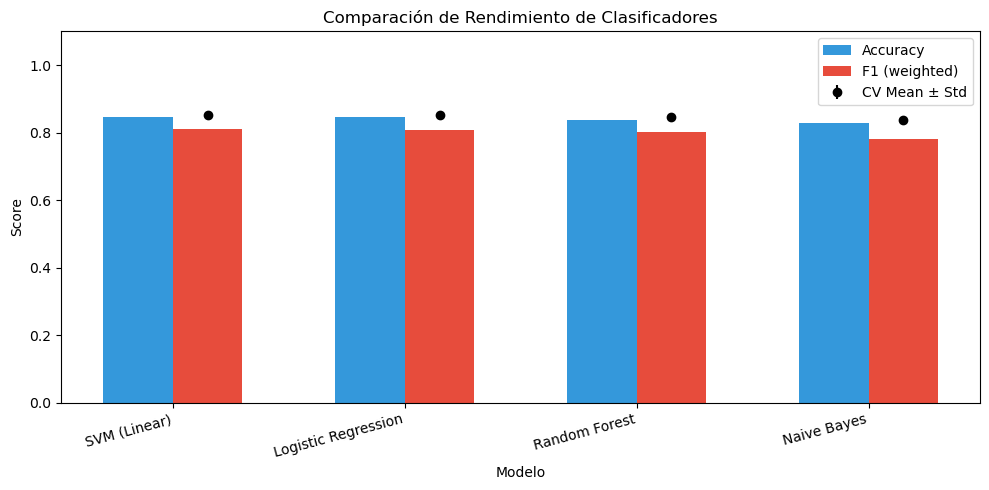

In [13]:
# ============================================================
# 4.3 Comparación Visual de Modelos
# ============================================================

# Tabla comparativa
comparison_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'F1 (weighted)': [r['f1_weighted'] for r in results.values()],
    'CV Mean': [r['cv_mean'] for r in results.values()],
    'CV Std': [r['cv_std'] for r in results.values()]
}).sort_values('F1 (weighted)', ascending=False)

print("=" * 70)
print("COMPARACIÓN DE MODELOS")
print("=" * 70)
print(comparison_df.to_string(index=False))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.3

ax.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x + width/2, comparison_df['F1 (weighted)'], width, label='F1 (weighted)', color='#e74c3c')
ax.errorbar(x + width/2, comparison_df['CV Mean'], yerr=comparison_df['CV Std'],
            fmt='o', color='black', label='CV Mean ± Std')

ax.set_xlabel('Modelo')
ax.set_ylabel('Score')
ax.set_title('Comparación de Rendimiento de Clasificadores')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Modelo'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()


CLASSIFICATION REPORT: SVM (Linear)
              precision    recall  f1-score   support

    Negative       0.77      0.55      0.64       447
     Neutral       0.38      0.01      0.03       215
    Positive       0.86      0.98      0.91      2331

    accuracy                           0.85      2993
   macro avg       0.67      0.52      0.53      2993
weighted avg       0.81      0.85      0.81      2993


CLASSIFICATION REPORT: Logistic Regression
              precision    recall  f1-score   support

    Negative       0.79      0.53      0.63       447
     Neutral       0.43      0.01      0.03       215
    Positive       0.85      0.98      0.91      2331

    accuracy                           0.85      2993
   macro avg       0.69      0.51      0.53      2993
weighted avg       0.81      0.85      0.81      2993



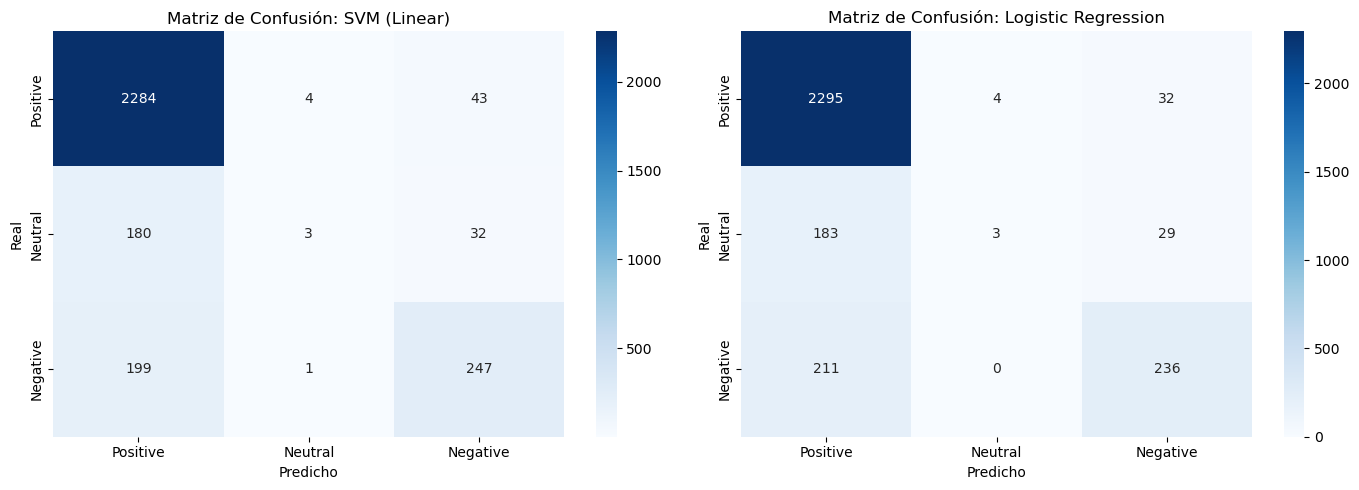


Mejor modelo seleccionado: SVM (Linear)
  Accuracy: 0.8466
  F1 (weighted): 0.8103


In [14]:
# ============================================================
# 4.4 Classification Reports y Matrices de Confusión
# ============================================================

# Seleccionar los dos mejores modelos para análisis detallado
best_two = comparison_df['Modelo'].head(2).tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, model_name in enumerate(best_two):
    result = results[model_name]

    # Classification Report
    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT: {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_test, result['y_pred']))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, result['y_pred'], labels=['Positive', 'Neutral', 'Negative'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Positive', 'Neutral', 'Negative'],
                yticklabels=['Positive', 'Neutral', 'Negative'],
                ax=axes[idx])
    axes[idx].set_title(f'Matriz de Confusión: {model_name}')
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Seleccionar el mejor modelo
best_model_name = comparison_df.iloc[0]['Modelo']
best_model = results[best_model_name]['model']
print(f"\nMejor modelo seleccionado: {best_model_name}")
print(f"  Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  F1 (weighted): {results[best_model_name]['f1_weighted']:.4f}")

In [15]:
# ============================================================
# 4.5 Análisis de Features más Importantes (TF-IDF)
# ============================================================

# Obtener los términos más relevantes para cada clase de sentimiento
# Esto aplica para Logistic Regression (tiene coeficientes interpretables)
if 'Logistic Regression' in results:
    lr_model = results['Logistic Regression']['model']
    feature_names = tfidf_vectorizer.get_feature_names_out()

    print("=" * 60)
    print("PALABRAS MÁS RELEVANTES POR SENTIMIENTO")
    print("(Basado en coeficientes de Logistic Regression)")
    print("=" * 60)

    for i, label in enumerate(lr_model.classes_):
        top_indices = lr_model.coef_[i].argsort()[-15:][::-1]
        top_features = [(feature_names[j], lr_model.coef_[i][j]) for j in top_indices]

        print(f"\n{label.upper()}:")
        for feat, score in top_features:
            print(f"  {feat:25s} → {score:.4f}")

PALABRAS MÁS RELEVANTES POR SENTIMIENTO
(Basado en coeficientes de Logistic Regression)

NEGATIVE:
  worst                     → 2.9304
  poor                      → 2.8056
  return                    → 2.4301
  waste                     → 2.0420
  hang                      → 1.8041
  working                   → 1.7916
  pathetic                  → 1.7593
  bad                       → 1.6832
  dont buy                  → 1.6765
  defective                 → 1.6709
  slow                      → 1.6427
  replace                   → 1.3981
  useless                   → 1.3929
  disappointed              → 1.3159
  received                  → 1.3137

NEUTRAL:
  average                   → 2.1622
  pin                       → 1.2264
  product ok                → 1.1654
  nice book                 → 1.1578
  come                      → 1.1129
  stand                     → 1.1128
  life great                → 1.0277
  fit                       → 1.0141
  sometimes                 → 0.9914
  l

---
## 5. Módulo 2: Identificación de Temas — LDA Topic Modeling

### Objetivo
Identificar los temas principales presentes en los comentarios de los clientes, permitiendo agruparlos en categorías como calidad, servicio, precio o entrega.

### Técnicas
- Tokenización de textos preprocesados
- Construcción de diccionario y corpus con Gensim
- Modelado de temas con **Latent Dirichlet Allocation (LDA)**
- Extracción de palabras clave por tema

In [16]:
# ============================================================
# 5.1 Preparación del Corpus para LDA
# ============================================================

# Tokenizar textos preprocesados en listas de palabras
texts_tokenized = [text.split() for text in df_sample['processed_text']]

# Crear diccionario (mapeo palabra → id)
dictionary = corpora.Dictionary(texts_tokenized)

# Filtrar extremos: palabras en menos de 5 documentos o más del 50%
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Crear corpus Bag of Words
corpus = [dictionary.doc2bow(text) for text in texts_tokenized]

print(f"Diccionario: {len(dictionary)} términos únicos")
print(f"Corpus: {len(corpus)} documentos")
print(f"\nEjemplo de documento BoW (primeros 10 términos):")
print(corpus[0][:10])

Diccionario: 2342 términos únicos
Corpus: 9976 documentos

Ejemplo de documento BoW (primeros 10 términos):
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 2), (6, 1), (7, 1), (8, 1), (9, 1)]


In [17]:
# ============================================================
# 5.2 Entrenamiento del Modelo LDA
# ============================================================

NUM_TOPICS = 5  # Número de temas a identificar

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

# Mostrar temas identificados con sus palabras clave
print("=" * 60)
print(f"TEMAS IDENTIFICADOS (LDA con {NUM_TOPICS} temas)")
print("=" * 60)

for idx, topic in lda_model.print_topics(-1, num_words=10):
    print(f"\nTema {idx + 1}:")
    # Formatear las palabras del tema
    words = topic.split(' + ')
    for w in words:
        weight, word = w.split('*')
        print(f"  {word.strip().strip('\"'):20s} (peso: {float(weight.strip()):.4f})")

TEMAS IDENTIFICADOS (LDA con 5 temas)

Tema 1:
  good                 (peso: 0.1200)
  product              (peso: 0.0900)
  quality              (peso: 0.0520)
  sound                (peso: 0.0340)
  amazon               (peso: 0.0230)
  price                (peso: 0.0170)
  working              (peso: 0.0160)
  picture              (peso: 0.0150)
  excellent            (peso: 0.0120)
  tv                   (peso: 0.0120)

Tema 2:
  phone                (peso: 0.0700)
  camera               (peso: 0.0580)
  good                 (peso: 0.0560)
  battery              (peso: 0.0380)
  quality              (peso: 0.0260)
  best                 (peso: 0.0240)
  price                (peso: 0.0200)
  life                 (peso: 0.0180)
  better               (peso: 0.0140)
  performance          (peso: 0.0140)

Tema 3:
  phone                (peso: 0.0300)
  battery              (peso: 0.0220)
  day                  (peso: 0.0210)
  time                 (peso: 0.0170)
  charge               

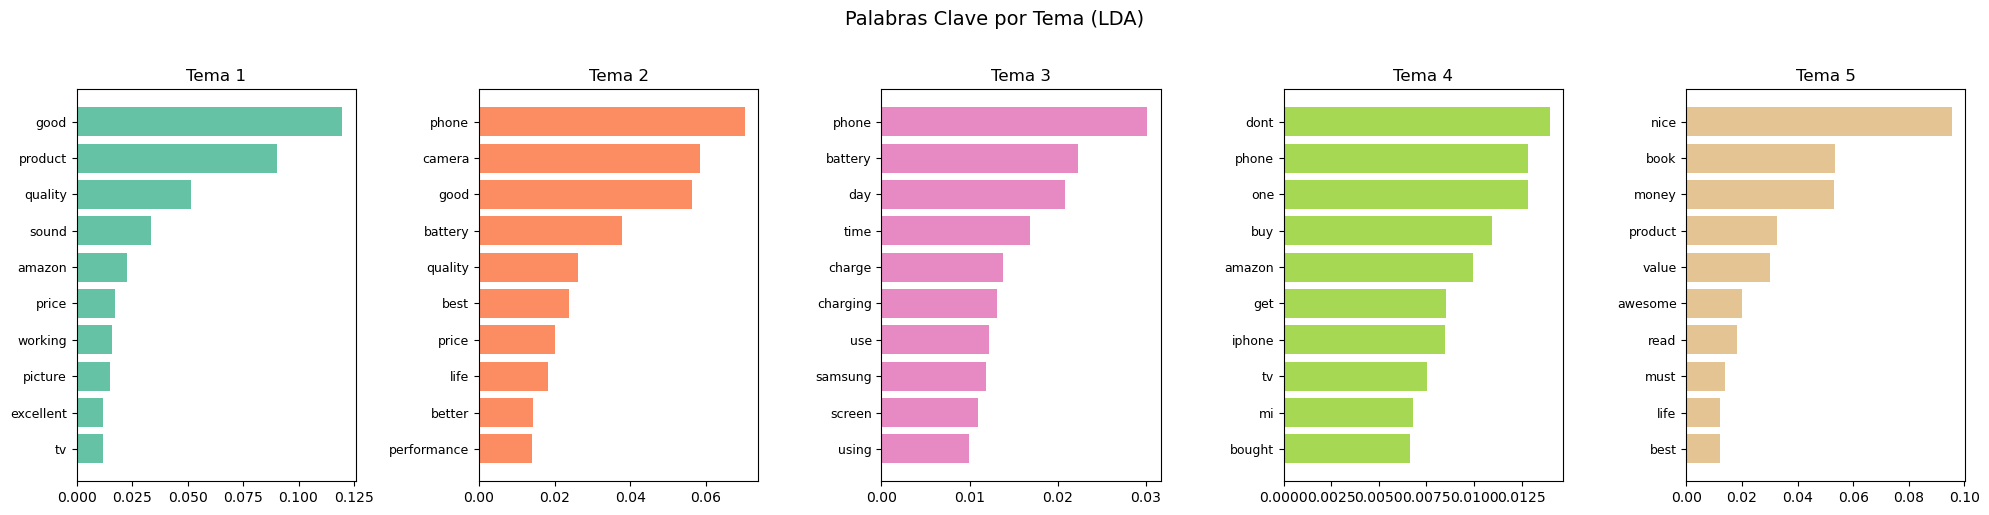

In [18]:
# ============================================================
# 5.3 Visualización de Temas
# ============================================================

# Obtener las top palabras por tema para visualización
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(20, 5), sharey=False)

for idx in range(NUM_TOPICS):
    topic_words = lda_model.show_topic(idx, topn=10)
    words = [w[0] for w in topic_words]
    weights = [w[1] for w in topic_words]

    axes[idx].barh(range(len(words)), weights, color=plt.cm.Set2(idx / NUM_TOPICS))
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words, fontsize=9)
    axes[idx].set_title(f'Tema {idx + 1}', fontsize=12)
    axes[idx].invert_yaxis()

plt.suptitle('Palabras Clave por Tema (LDA)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

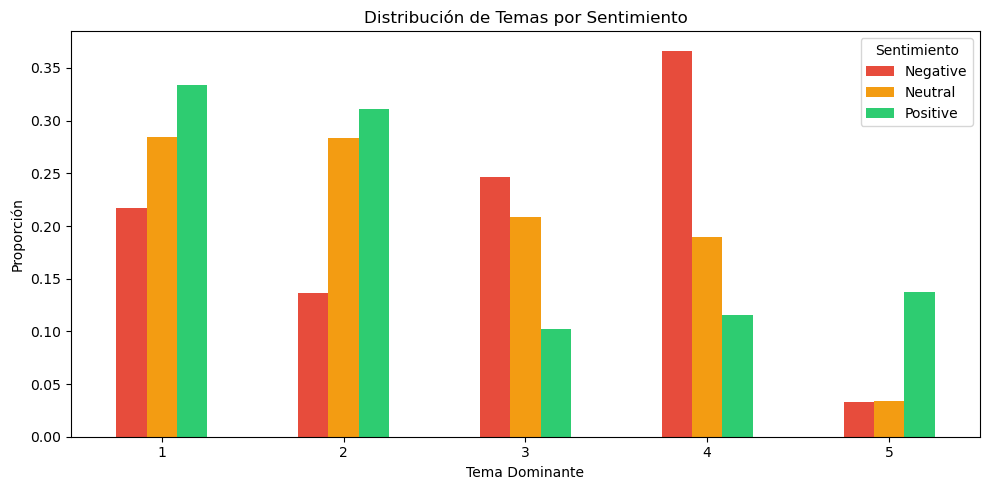


Distribución de temas por sentimiento (proporciones):
Own_Rating      Negative  Neutral  Positive
dominant_topic                             
1                  0.217    0.285     0.333
2                  0.136    0.284     0.311
3                  0.247    0.208     0.102
4                  0.366    0.190     0.116
5                  0.033    0.034     0.137


In [19]:
# ============================================================
# 5.4 Distribución de Temas por Sentimiento
# ============================================================

def get_dominant_topic(bow_doc, model):
    """Obtiene el tema dominante para un documento."""
    topic_distribution = model.get_document_topics(bow_doc)
    if topic_distribution:
        return max(topic_distribution, key=lambda x: x[1])
    return (0, 0.0)

# Asignar tema dominante a cada documento
dominant_topics = []
topic_probs = []
for doc_bow in corpus:
    topic, prob = get_dominant_topic(doc_bow, lda_model)
    dominant_topics.append(topic + 1)  # Temas desde 1
    topic_probs.append(prob)

df_sample['dominant_topic'] = dominant_topics
df_sample['topic_probability'] = topic_probs

# Distribución de temas por sentimiento
topic_sentiment = pd.crosstab(
    df_sample['dominant_topic'],
    df_sample['Own_Rating'],
    normalize='columns'
)

fig, ax = plt.subplots(figsize=(10, 5))
topic_sentiment.plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('Distribución de Temas por Sentimiento')
ax.set_xlabel('Tema Dominante')
ax.set_ylabel('Proporción')
ax.legend(title='Sentimiento')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nDistribución de temas por sentimiento (proporciones):")
print(topic_sentiment.round(3))

---
## 6. Módulo 3: Análisis Sintáctico-Semántico

### Objetivo
Extraer estructuras gramaticales y patrones semánticos de los textos para proporcionar una capa de **explicabilidad** a las predicciones del modelo de sentimientos.

### Técnicas (siguiendo NLP_POS_NER_Clase.ipynb)
- **POS Tagging** (Part-of-Speech Tagging) con spaCy
- **Named Entity Recognition (NER)**
- **Dependency Parsing** — análisis de dependencias gramaticales
- **Extracción de patrones sintácticos**: ADJ+NOUN, VERB+NOUN
- Identificación de frases opinativas clave

In [20]:
# ============================================================
# 6.1 Clase SyntacticSemanticAnalyzer
# ============================================================

class SyntacticSemanticAnalyzer:
    """Analiza textos extrayendo POS tags, NER, y patrones lingüísticos."""

    def __init__(self, spacy_model):
        self.nlp = spacy_model

    def analyze(self, text):
        """Análisis completo de un texto: tokens, POS, NER, patrones."""
        doc = self.nlp(text)

        # Tokens con información lingüística
        token_info = [{
            'text': token.text,
            'lemma': token.lemma_,
            'pos': token.pos_,
            'tag': token.tag_,
            'dep': token.dep_,
            'is_stop': token.is_stop
        } for token in doc if not token.is_punct and not token.is_space]

        # Named Entities
        entities = [(ent.text, ent.label_) for ent in doc.ents]

        # Patrones ADJ + NOUN
        adj_noun_patterns = self._extract_adj_noun(doc)

        # Patrones VERB + NOUN
        verb_noun_patterns = self._extract_verb_noun(doc)

        return {
            'tokens': token_info,
            'entities': entities,
            'adj_noun_patterns': adj_noun_patterns,
            'verb_noun_patterns': verb_noun_patterns,
            'num_tokens': len(token_info),
            'num_entities': len(entities)
        }

    def _extract_adj_noun(self, doc):
        """Extrae patrones ADJ + NOUN (ej. 'poor quality', 'excellent service')."""
        patterns = []
        for i in range(len(doc) - 1):
            if doc[i].pos_ == 'ADJ' and doc[i + 1].pos_ == 'NOUN':
                patterns.append(f"{doc[i].text} {doc[i + 1].text}")
        return patterns

    def _extract_verb_noun(self, doc):
        """Extrae patrones VERB + NOUN (ej. 'recommend product', 'love quality')."""
        patterns = []
        for token in doc:
            if token.pos_ == 'VERB' and not token.is_stop:
                for child in token.children:
                    if child.pos_ == 'NOUN':
                        patterns.append(f"{token.lemma_} {child.text}")
        return patterns

analyzer = SyntacticSemanticAnalyzer(nlp)
print("SyntacticSemanticAnalyzer inicializado correctamente.")

SyntacticSemanticAnalyzer inicializado correctamente.


In [21]:
# ============================================================
# 6.2 Demostración con Reseñas de Ejemplo
# ============================================================

# Seleccionar ejemplos representativos (uno por sentimiento)
examples = []
for sentiment in ['Positive', 'Negative', 'Neutral']:
    sample = df_sample[df_sample['Own_Rating'] == sentiment].sample(1, random_state=42)
    examples.append(sample.iloc[0])

for example in examples:
    print(f"\n{'='*70}")
    print(f"SENTIMIENTO: {example['Own_Rating']}")
    print(f"{'='*70}")
    print(f"Texto original: {example['Review_text'][:200]}...")

    result = analyzer.analyze(example['Review_text'])

    # POS Distribution
    pos_counts = Counter([t['pos'] for t in result['tokens']])
    print(f"\nDistribución POS: {dict(pos_counts.most_common(5))}")

    # Named Entities
    if result['entities']:
        print(f"Entidades Nombradas: {result['entities'][:5]}")
    else:
        print("Entidades Nombradas: No se encontraron")

    # Patrones ADJ+NOUN
    if result['adj_noun_patterns']:
        print(f"Patrones ADJ+NOUN: {result['adj_noun_patterns'][:8]}")
    else:
        print("Patrones ADJ+NOUN: No se encontraron")

    # Patrones VERB+NOUN
    if result['verb_noun_patterns']:
        print(f"Patrones VERB+NOUN: {result['verb_noun_patterns'][:8]}")
    else:
        print("Patrones VERB+NOUN: No se encontraron")


SENTIMIENTO: Positive
Texto original: Standard product standard value.....good speed of transer and no techinacal problems...

Distribución POS: {'NOUN': 5, 'ADJ': 4, 'ADP': 1, 'CCONJ': 1, 'DET': 1}
Entidades Nombradas: [('Standard', 'ORG')]
Patrones ADJ+NOUN: ['Standard product', 'standard value', 'good speed', 'techinacal problems']
Patrones VERB+NOUN: No se encontraron

SENTIMIENTO: Negative
Texto original: Samsung Note 5 mother board got damaged after using this charger . As per technician its due to over heat during charging .Be careful if your phone gets over heated while using this power bank...

Distribución POS: {'NOUN': 10, 'ADP': 6, 'VERB': 5, 'ADJ': 3, 'PROPN': 2}
Entidades Nombradas: [('Samsung Note', 'PERSON'), ('5', 'CARDINAL')]
Patrones ADJ+NOUN: ['due to']
Patrones VERB+NOUN: ['damage board', 'charge .Be', 'get phone']

SENTIMIENTO: Neutral
Texto original: Good at this price....

Distribución POS: {'ADJ': 1, 'ADP': 1, 'DET': 1, 'NOUN': 1}
Entidades Nombradas: No se en

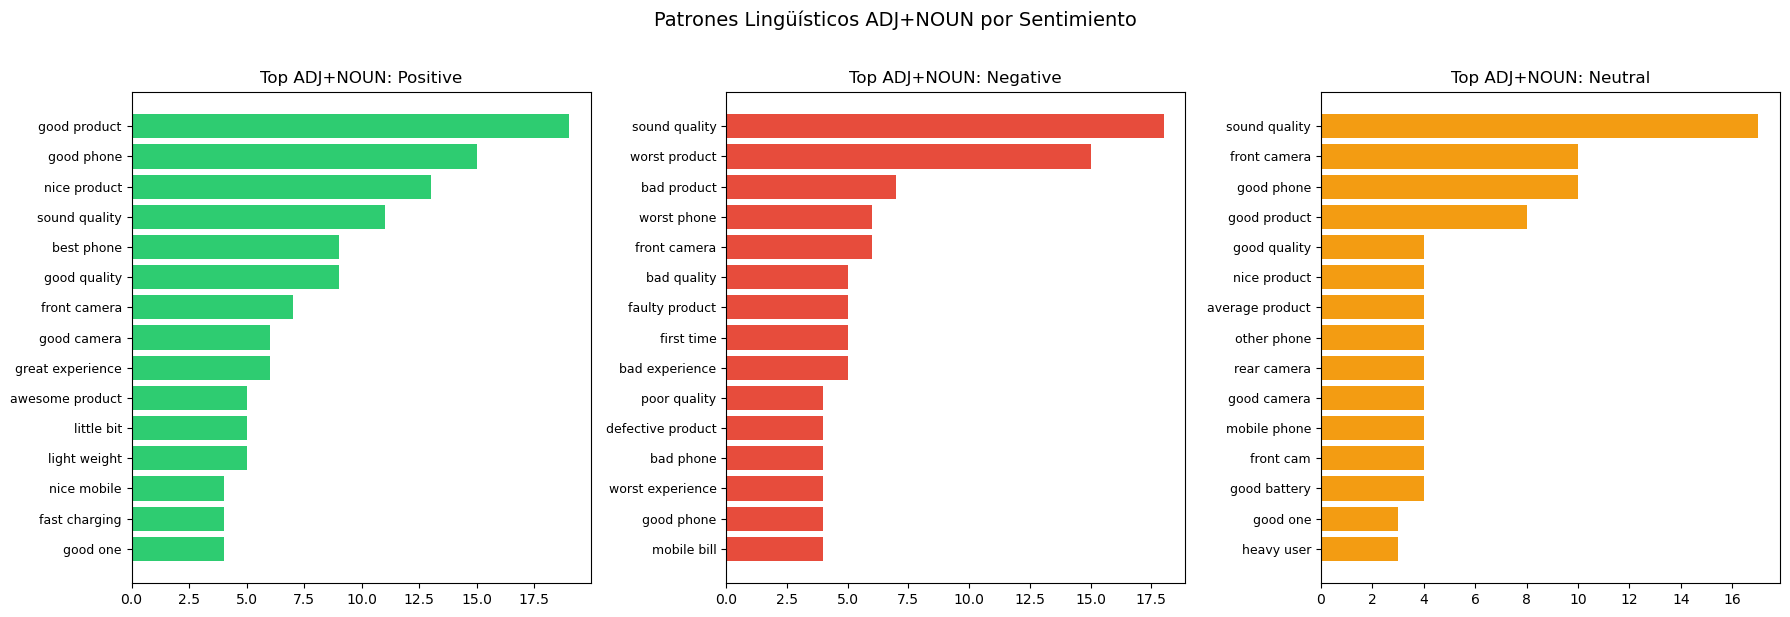

In [22]:
# ============================================================
# 6.3 Análisis de Patrones a Escala: ADJ+NOUN por Sentimiento
# ============================================================

# Extraer patrones ADJ+NOUN de una muestra más grande
ANALYSIS_SAMPLE = 500

patterns_by_sentiment = {'Positive': [], 'Negative': [], 'Neutral': []}

for sentiment in ['Positive', 'Negative', 'Neutral']:
    subset = df_sample[df_sample['Own_Rating'] == sentiment].sample(
        min(ANALYSIS_SAMPLE, len(df_sample[df_sample['Own_Rating'] == sentiment])),
        random_state=42
    )
    for text in subset['Review_text']:
        try:
            result = analyzer.analyze(str(text))
            patterns_by_sentiment[sentiment].extend(result['adj_noun_patterns'])
        except Exception:
            continue

# Top patrones por sentimiento
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (sentiment, patterns) in enumerate(patterns_by_sentiment.items()):
    pattern_counts = Counter([p.lower() for p in patterns]).most_common(15)
    if pattern_counts:
        words, counts = zip(*pattern_counts)
        axes[idx].barh(range(len(words)), counts,
                       color=colors_sentiment[sentiment])
        axes[idx].set_yticks(range(len(words)))
        axes[idx].set_yticklabels(words, fontsize=9)
        axes[idx].set_title(f'Top ADJ+NOUN: {sentiment}', fontsize=12)
        axes[idx].invert_yaxis()

plt.suptitle('Patrones Lingüísticos ADJ+NOUN por Sentimiento', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Integración: Pipeline Completo de Análisis

### Objetivo
Crear un pipeline unificado que, dado un texto de entrada, ejecute los tres módulos y produzca una salida estructurada que combine:
- **Sentimiento predicho** con nivel de confianza
- **Tema identificado** con palabras clave
- **Patrones lingüísticos** extraídos (ADJ+NOUN, entidades)
- **Evidencia textual** que respalde la predicción

Esta integración demuestra la relación entre módulos: el sentimiento identifica la polaridad, los temas contextualizan el contenido, y el análisis sintáctico explica las razones lingüísticas.

In [23]:
# ============================================================
# 7.1 Pipeline Integrado de Análisis
# ============================================================

class ReviewAnalysisPipeline:
    """Pipeline completo que integra los tres módulos del POC."""

    def __init__(self, preprocessor, vectorizer, classifier, lda_model,
                 dictionary, syntactic_analyzer, classifier_name=""):
        self.preprocessor = preprocessor
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.lda_model = lda_model
        self.dictionary = dictionary
        self.syntactic_analyzer = syntactic_analyzer
        self.classifier_name = classifier_name

    def analyze(self, text):
        """Análisis completo de una reseña integrando los 3 módulos."""

        # Módulo 1: Análisis de Sentimientos
        processed = self.preprocessor.preprocess(text)
        tfidf_vector = self.vectorizer.transform([processed])
        sentiment = self.classifier.predict(tfidf_vector)[0]

        # Obtener probabilidades si el modelo lo soporta
        confidence = None
        if hasattr(self.classifier, 'predict_proba'):
            proba = self.classifier.predict_proba(tfidf_vector)[0]
            confidence = dict(zip(self.classifier.classes_, proba.round(4)))

        # Top features TF-IDF del texto
        feature_names = self.vectorizer.get_feature_names_out()
        tfidf_scores = tfidf_vector.toarray()[0]
        top_features_idx = tfidf_scores.argsort()[-10:][::-1]
        top_features = [(feature_names[i], tfidf_scores[i])
                        for i in top_features_idx if tfidf_scores[i] > 0]

        # Módulo 2: Identificación de Temas
        tokens = processed.split()
        bow = self.dictionary.doc2bow(tokens)
        topic_dist = self.lda_model.get_document_topics(bow)
        if topic_dist:
            dominant_topic_id, dominant_topic_prob = max(topic_dist, key=lambda x: x[1])
            topic_words = [w[0] for w in self.lda_model.show_topic(dominant_topic_id, topn=5)]
        else:
            dominant_topic_id, dominant_topic_prob = 0, 0.0
            topic_words = []

        # Módulo 3: Análisis Sintáctico-Semántico
        syntactic_result = self.syntactic_analyzer.analyze(text)

        return {
            'input_text': text,
            'processed_text': processed,
            'sentiment': {
                'label': sentiment,
                'confidence': confidence,
                'model': self.classifier_name
            },
            'topic': {
                'id': dominant_topic_id + 1,
                'probability': round(dominant_topic_prob, 4),
                'keywords': topic_words
            },
            'syntactic': {
                'adj_noun_patterns': syntactic_result['adj_noun_patterns'],
                'verb_noun_patterns': syntactic_result['verb_noun_patterns'],
                'entities': syntactic_result['entities'],
                'num_tokens': syntactic_result['num_tokens']
            },
            'key_features': top_features[:5]
        }

    def display(self, result):
        """Muestra los resultados del análisis de forma estructurada."""
        print("=" * 70)
        print("ANÁLISIS INTEGRADO DE RESEÑA")
        print("=" * 70)
        print(f"\nTexto: \"{result['input_text'][:200]}{'...' if len(result['input_text']) > 200 else ''}\"")

        # Sentimiento
        print(f"\n--- SENTIMIENTO ({result['sentiment']['model']}) ---")
        print(f"  Predicción: {result['sentiment']['label']}")
        if result['sentiment']['confidence']:
            for label, prob in sorted(result['sentiment']['confidence'].items(),
                                       key=lambda x: x[1], reverse=True):
                bar = '█' * int(prob * 30)
                print(f"  {label:10s}: {bar} {prob:.4f}")

        # Tema
        print(f"\n--- TEMA IDENTIFICADO ---")
        print(f"  Tema: {result['topic']['id']} (prob: {result['topic']['probability']:.4f})")
        print(f"  Palabras clave: {', '.join(result['topic']['keywords'])}")

        # Patrones lingüísticos
        print(f"\n--- ANÁLISIS SINTÁCTICO ---")
        print(f"  Tokens: {result['syntactic']['num_tokens']}")
        if result['syntactic']['adj_noun_patterns']:
            print(f"  ADJ+NOUN: {', '.join(result['syntactic']['adj_noun_patterns'][:5])}")
        if result['syntactic']['verb_noun_patterns']:
            print(f"  VERB+NOUN: {', '.join(result['syntactic']['verb_noun_patterns'][:5])}")
        if result['syntactic']['entities']:
            print(f"  Entidades: {result['syntactic']['entities'][:5]}")

        # Features clave
        if result['key_features']:
            print(f"\n--- EVIDENCIA TEXTUAL (Top TF-IDF) ---")
            for feat, score in result['key_features']:
                print(f"  {feat:20s} → {score:.4f}")

# Instanciar el pipeline con el mejor modelo
# Usar Logistic Regression para tener predict_proba
lr_model = results['Logistic Regression']['model']

pipeline = ReviewAnalysisPipeline(
    preprocessor=preprocessor,
    vectorizer=tfidf_vectorizer,
    classifier=lr_model,
    lda_model=lda_model,
    dictionary=dictionary,
    syntactic_analyzer=analyzer,
    classifier_name="Logistic Regression"
)

print("Pipeline integrado creado correctamente.")

Pipeline integrado creado correctamente.


In [24]:
# ============================================================
# 7.2 Demostración del Pipeline Integrado
# ============================================================

# Textos de ejemplo para demostración
demo_texts = [
    "This phone is absolutely amazing! The camera quality is excellent and the battery life is incredible. Best purchase I ever made.",
    "Terrible product. Screen broke after two days. Very poor quality and the customer service was horrible. Complete waste of money.",
    "The TV is okay for the price. Nothing special but it works. Average picture quality and decent sound.",
    "I love this book! The author explains complex topics in a simple way. Highly recommend for anyone interested in the subject.",
    "The refrigerator stopped working after one month. Very disappointed with Samsung. Do not buy this product."
]

for text in demo_texts:
    result = pipeline.analyze(text)
    pipeline.display(result)
    print()

ANÁLISIS INTEGRADO DE RESEÑA

Texto: "This phone is absolutely amazing! The camera quality is excellent and the battery life is incredible. Best purchase I ever made."

--- SENTIMIENTO (Logistic Regression) ---
  Predicción: Positive
  Positive  : █████████████████████████████ 0.9829
  Neutral   :  0.0093
  Negative  :  0.0078

--- TEMA IDENTIFICADO ---
  Tema: 2 (prob: 0.9355)
  Palabras clave: phone, camera, good, battery, quality

--- ANÁLISIS SINTÁCTICO ---
  Tokens: 21
  ADJ+NOUN: Best purchase

--- EVIDENCIA TEXTUAL (Top TF-IDF) ---
  incredible           → 0.3780
  excellent battery    → 0.3532
  quality excellent    → 0.3491
  absolutely           → 0.3256
  made                 → 0.2819

ANÁLISIS INTEGRADO DE RESEÑA

Texto: "Terrible product. Screen broke after two days. Very poor quality and the customer service was horrible. Complete waste of money."

--- SENTIMIENTO (Logistic Regression) ---
  Predicción: Negative
  Negative  : █████████████████████████ 0.8583
  Positive  :

---
## 8. Capa de Explicabilidad: Predicciones Basadas en Evidencia

### Objetivo
Demostrar que el sistema no solo predice una categoría, sino que también proporciona:
- Palabras clave relevantes (TF-IDF features)
- Estructuras lingüísticas identificadas (patrones ADJ+NOUN, VERB+NOUN)
- Evidencia textual que respalda la predicción

Esto permite generar conclusiones interpretables como:
> *"Los comentarios negativos se concentran principalmente en problemas relacionados con la calidad del producto y el tiempo de entrega, evidenciados por la presencia de términos como 'poor quality' y 'late delivery'."*

In [25]:
# ============================================================
# 8.1 Análisis de Explicabilidad sobre Datos Reales
# ============================================================

# Seleccionar reseñas reales del dataset para explicabilidad
sample_reviews = []
for sentiment in ['Positive', 'Negative', 'Neutral']:
    reviews = df_sample[
        (df_sample['Own_Rating'] == sentiment) &
        (df_sample['Review_text'].str.len() > 50) &
        (df_sample['Review_text'].str.len() < 500)
    ].sample(2, random_state=42)
    sample_reviews.append(reviews)

sample_df = pd.concat(sample_reviews).reset_index(drop=True)

# Analizar cada reseña con el pipeline completo
print("=" * 70)
print("ANÁLISIS DE EXPLICABILIDAD - RESEÑAS REALES DEL DATASET")
print("=" * 70)

explanations = []
for _, row in sample_df.iterrows():
    result = pipeline.analyze(row['Review_text'])

    explanation = {
        'Text (excerpt)': row['Review_text'][:100] + '...',
        'Real Label': row['Own_Rating'],
        'Predicted': result['sentiment']['label'],
        'Correct': '✓' if row['Own_Rating'] == result['sentiment']['label'] else '✗',
        'Topic': result['topic']['id'],
        'Topic Keywords': ', '.join(result['topic']['keywords'][:3]),
        'ADJ+NOUN Patterns': ', '.join(result['syntactic']['adj_noun_patterns'][:3]) or 'N/A',
        'Top TF-IDF Terms': ', '.join([f[0] for f in result['key_features'][:3]]) or 'N/A'
    }
    explanations.append(explanation)

    pipeline.display(result)
    print(f"\n  >> Etiqueta Real: {row['Own_Rating']} | "
          f"Predicción: {result['sentiment']['label']} | "
          f"{'✓ CORRECTO' if row['Own_Rating'] == result['sentiment']['label'] else '✗ INCORRECTO'}")
    print()

ANÁLISIS DE EXPLICABILIDAD - RESEÑAS REALES DEL DATASET
ANÁLISIS INTEGRADO DE RESEÑA

Texto: "Phone is very good and battery life is good but in the box earspring is not given"

--- SENTIMIENTO (Logistic Regression) ---
  Predicción: Positive
  Positive  : █████████████████████████ 0.8386
  Neutral   : ███ 0.1302
  Negative  :  0.0313

--- TEMA IDENTIFICADO ---
  Tema: 2 (prob: 0.6568)
  Palabras clave: phone, camera, good, battery, quality

--- ANÁLISIS SINTÁCTICO ---
  Tokens: 17

--- EVIDENCIA TEXTUAL (Top TF-IDF) ---
  given                → 0.4079
  life good            → 0.3869
  box                  → 0.3776
  phone good           → 0.3728
  good battery         → 0.3537

  >> Etiqueta Real: Positive | Predicción: Positive | ✓ CORRECTO

ANÁLISIS INTEGRADO DE RESEÑA

Texto: "Camera is great, battery life could be better. Gaming performance is average."

--- SENTIMIENTO (Logistic Regression) ---
  Predicción: Positive
  Positive  : ███████████████████████████ 0.9049
  Neutral   : 

In [26]:
# ============================================================
# 8.2 Tabla Resumen de Explicabilidad
# ============================================================

explanations_df = pd.DataFrame(explanations)

print("=" * 70)
print("TABLA RESUMEN DE EXPLICABILIDAD")
print("=" * 70)
print(explanations_df[['Real Label', 'Predicted', 'Correct', 'Topic',
                        'Topic Keywords', 'ADJ+NOUN Patterns']].to_string(index=False))

# Accuracy sobre la muestra de explicabilidad
correct = sum(1 for e in explanations if e['Correct'] == '✓')
print(f"\nPredicciones correctas: {correct}/{len(explanations)}")

TABLA RESUMEN DE EXPLICABILIDAD
Real Label Predicted Correct  Topic      Topic Keywords    ADJ+NOUN Patterns
  Positive  Positive       ✓      2 phone, camera, good                  N/A
  Positive  Positive       ✓      2 phone, camera, good                  N/A
  Negative  Positive       ✗      4    dont, phone, one                  N/A
  Negative  Negative       ✓      4    dont, phone, one     original product
   Neutral  Positive       ✗      2 phone, camera, good        great chipset
   Neutral  Positive       ✗      5   nice, book, money grammatical mistakes

Predicciones correctas: 3/6


---
## 9. Resumen de Resultados y Conclusiones

### Resumen del POC
Este POC implementa exitosamente tres módulos integrados de Procesamiento de Lenguaje Natural para el análisis automatizado de reseñas de clientes de Amazon:

| Módulo | Técnicas | Funcionalidad |
|--------|----------|---------------|
| **1. Análisis de Sentimientos** | TF-IDF + Logistic Regression, Naive Bayes, SVM, Random Forest | Clasifica reseñas en Positivo/Negativo/Neutro |
| **2. Identificación de Temas** | Gensim LDA (Latent Dirichlet Allocation) | Identifica temas principales y palabras clave |
| **3. Análisis Sintáctico-Semántico** | spaCy POS Tagging, NER, Dependency Parsing | Extrae patrones ADJ+NOUN, VERB+NOUN, entidades |

### Librerías Utilizadas
- **NLTK**: Tokenización, stopwords, lematización
- **spaCy**: POS tagging, NER, dependency parsing
- **scikit-learn**: TF-IDF, clasificación supervisada, evaluación
- **Gensim**: Topic modeling (LDA)
- **pandas/numpy/matplotlib/seaborn**: Manejo de datos y visualización

### Relación entre Módulos
Los tres módulos se integran en un pipeline unificado que proporciona una visión completa:
- El **análisis de sentimientos** identifica la polaridad de la opinión
- La **identificación de temas** contextualiza el contenido de la opinión
- El **análisis sintáctico-semántico** explica las razones lingüísticas detrás de la clasificación

### Capa de Explicabilidad
El sistema no solo predice una categoría, sino que proporciona evidencia textual mediante:
- Palabras clave TF-IDF que contribuyen a la predicción
- Patrones lingüísticos (ADJ+NOUN) identificados en el texto
- Asignación de tema con palabras clave asociadas

### Alcance
Este POC demuestra la viabilidad técnica del enfoque propuesto. No busca optimización para producción, sino validar el enfoque metodológico y técnico del proyecto.

In [27]:
# ============================================================
# 9.1 Resumen Final de Métricas
# ============================================================

print("=" * 70)
print("RESUMEN FINAL DEL POC")
print("=" * 70)

print(f"\n📊 DATASET")
print(f"  Total reseñas: {len(df):,}")
print(f"  Muestra utilizada: {len(df_sample):,}")
print(f"  Categorías: {', '.join(df['Category'].unique())}")

print(f"\n🎯 MÓDULO 1: ANÁLISIS DE SENTIMIENTOS")
print(f"  Mejor modelo: {best_model_name}")
print(f"  Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  F1 (weighted): {results[best_model_name]['f1_weighted']:.4f}")
print(f"  Cross-Validation: {results[best_model_name]['cv_mean']:.4f} (+/- {results[best_model_name]['cv_std']:.4f})")
print(f"  Features TF-IDF: {X.shape[1]}")

print(f"\n📋 MÓDULO 2: IDENTIFICACIÓN DE TEMAS")
print(f"  Número de temas: {NUM_TOPICS}")
print(f"  Vocabulario LDA: {len(dictionary)} términos")

print(f"\n🔍 MÓDULO 3: ANÁLISIS SINTÁCTICO-SEMÁNTICO")
print(f"  Modelo: spaCy en_core_web_sm")
print(f"  Técnicas: POS Tagging, NER, Dependency Parsing, ADJ+NOUN, VERB+NOUN")

print(f"\n✅ INTEGRACIÓN")
print(f"  Pipeline funcional que recibe texto y retorna:")
print(f"    → Sentimiento predicho + confianza")
print(f"    → Tema dominante + palabras clave")
print(f"    → Patrones lingüísticos + entidades")
print(f"    → Evidencia textual (top TF-IDF features)")

print(f"\n{'='*70}")
print("POC completado exitosamente.")
print(f"{'='*70}")

RESUMEN FINAL DEL POC

📊 DATASET
  Total reseñas: 60,857
  Muestra utilizada: 9,976
  Categorías: smartTv, mobile, books, mobile accessories, refrigerator

🎯 MÓDULO 1: ANÁLISIS DE SENTIMIENTOS
  Mejor modelo: SVM (Linear)
  Accuracy: 0.8466
  F1 (weighted): 0.8103
  Cross-Validation: 0.8529 (+/- 0.0040)
  Features TF-IDF: 5000

📋 MÓDULO 2: IDENTIFICACIÓN DE TEMAS
  Número de temas: 5
  Vocabulario LDA: 2342 términos

🔍 MÓDULO 3: ANÁLISIS SINTÁCTICO-SEMÁNTICO
  Modelo: spaCy en_core_web_sm
  Técnicas: POS Tagging, NER, Dependency Parsing, ADJ+NOUN, VERB+NOUN

✅ INTEGRACIÓN
  Pipeline funcional que recibe texto y retorna:
    → Sentimiento predicho + confianza
    → Tema dominante + palabras clave
    → Patrones lingüísticos + entidades
    → Evidencia textual (top TF-IDF features)

POC completado exitosamente.
